In [11]:
import re
import os
import time
from datetime import datetime, timedelta

import pandas as pd
import requests
from bs4 import BeautifulSoup


def parse_br_float(value: str) -> float:
    value = str(value).strip()
    value = value.replace(".", "").replace(",", ".")
    return float(value)


def extract_number_prefix(text: str) -> str:
    m = re.match(r"\d+", text.strip())
    return m.group(0) if m else text.strip()


def scrape_bmf_txref_day(date_obj: datetime, taxa: str = "APR"):

    data = date_obj.strftime("%d/%m/%Y")
    data1 = date_obj.strftime("%Y%m%d")

    url = "https://www2.bmf.com.br/pages/portal/bmfbovespa/boletim1/TxRef1.asp"

    params = {
        "Data": data,
        "Data1": data1,
        #"slcTaxa": taxa
    }

    headers = {"User-Agent": "Mozilla/5.0"}

    r = requests.get(url, params=params, headers=headers, timeout=30)
    r.raise_for_status()

    html = r.content.decode("latin1", errors="ignore")

    soup = BeautifulSoup(html, "html.parser")

    tables = soup.find_all("table")

    if len(tables) < 2:
        return pd.DataFrame()

    table = tables[1]

    header_items = table.find_all("td", class_="tabelaItem")

    curve_headers = [extract_number_prefix(x.get_text()) for x in header_items]

    if len(curve_headers) < 2:
        return pd.DataFrame()

    cells = table.find_all("td", class_=["tabelaConteudo1", "tabelaConteudo2"])

    values = [c.get_text(strip=True) for c in cells if c.get_text(strip=True)]

    if not values:
        return pd.DataFrame()

    rows = [values[i:i+3] for i in range(0, len(values), 3)]
    rows = [r for r in rows if len(r) == 3]

    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(rows, columns=["dias_corridos", curve_headers[0], curve_headers[1]])

    df["dias_corridos"] = df["dias_corridos"].astype(int)

    for col in curve_headers:
        df[col] = df[col].apply(parse_br_float)

    df = df.melt(
        id_vars=["dias_corridos"],
        var_name="convencao_dias",
        value_name="taxa"
    )

    df["data_referencia"] = pd.to_datetime(data1, format="%Y%m%d")
    df["tipo_taxa"] = taxa

    df = df[
        ["data_referencia", "tipo_taxa", "dias_corridos", "convencao_dias", "taxa"]
    ]

    return df


def load_existing_data(csv_path, parquet_path):

    if os.path.exists(parquet_path):
        print("Carregando histórico existente (parquet)")
        return pd.read_parquet(parquet_path)

    if os.path.exists(csv_path):
        print("Carregando histórico existente (csv)")
        return pd.read_csv(csv_path, sep=";", parse_dates=["data_referencia"])

    return pd.DataFrame()


def build_historico(data_inicio, data_fim):

    csv_path = "historico_txref.csv"
    parquet_path = "historico_txref.parquet"

    historico_existente = load_existing_data(csv_path, parquet_path)

    inicio = datetime.strptime(data_inicio, "%Y-%m-%d")
    fim = datetime.strptime(data_fim, "%Y-%m-%d")

    novos_dados = []

    current = inicio

    while current <= fim:

        if current.weekday() >= 5:
            current += timedelta(days=1)
            continue

        try:

            df_day = scrape_bmf_txref_day(current)

            if df_day.empty:
                print(f"[VAZIO] {current.date()}")
            else:
                novos_dados.append(df_day)
                print(f"[OK] {current.date()}")

        except Exception as e:
            print(f"[ERRO] {current.date()} -> {e}")

        time.sleep(0.1)

        current += timedelta(days=1)

    if not novos_dados:
        print("Nenhum dado novo.")
        return historico_existente

    df_novo = pd.concat(novos_dados, ignore_index=True)

    historico = pd.concat([historico_existente, df_novo], ignore_index=True)

    historico = historico.drop_duplicates(
        subset=["data_referencia", "tipo_taxa", "dias_corridos", "convencao_dias"]
    )

    historico = historico.sort_values(
        ["data_referencia", "dias_corridos", "convencao_dias"]
    )

    historico.to_csv(csv_path, sep=";", index=False, encoding="utf-8-sig")
    historico.to_parquet(parquet_path, index=False)

    print("\nHistórico atualizado")
    print("Linhas totais:", len(historico))

    return historico



In [19]:
historico = build_historico(
        data_inicio="2021-01-01",
        data_fim="2026-03-05",
    )

Carregando histórico existente (csv)
[VAZIO] 2021-01-01
[OK] 2021-01-04
[OK] 2021-01-05
[OK] 2021-01-06
[OK] 2021-01-07
[OK] 2021-01-08
[OK] 2021-01-11
[OK] 2021-01-12
[OK] 2021-01-13
[OK] 2021-01-14
[OK] 2021-01-15
[OK] 2021-01-18
[OK] 2021-01-19
[OK] 2021-01-20
[OK] 2021-01-21
[OK] 2021-01-22
[VAZIO] 2021-01-25
[OK] 2021-01-26
[OK] 2021-01-27
[OK] 2021-01-28
[OK] 2021-01-29
[OK] 2021-02-01
[OK] 2021-02-02
[OK] 2021-02-03
[OK] 2021-02-04
[OK] 2021-02-05
[OK] 2021-02-08
[OK] 2021-02-09
[OK] 2021-02-10
[OK] 2021-02-11
[OK] 2021-02-12
[VAZIO] 2021-02-15
[VAZIO] 2021-02-16
[OK] 2021-02-17
[OK] 2021-02-18
[OK] 2021-02-19
[OK] 2021-02-22
[OK] 2021-02-23
[OK] 2021-02-24
[OK] 2021-02-25
[OK] 2021-02-26
[OK] 2021-03-01
[OK] 2021-03-02
[OK] 2021-03-03
[OK] 2021-03-04
[OK] 2021-03-05
[OK] 2021-03-08
[OK] 2021-03-09
[OK] 2021-03-10
[OK] 2021-03-11
[OK] 2021-03-12
[OK] 2021-03-15
[OK] 2021-03-16
[OK] 2021-03-17
[OK] 2021-03-18
[OK] 2021-03-19
[OK] 2021-03-22
[OK] 2021-03-23
[OK] 2021-03-24
[OK] 20

ArrowKeyError: A type extension with name pandas.period already defined

In [25]:
aa = pd.read_csv('historico_txref.csv', sep=';', encoding="utf-8-sig")

In [37]:
df = pd.read_csv(
    "historico_txref.csv",
    sep=";",
    parse_dates=["data_referencia"]
)

In [50]:
data_escolhida = "2026-03-05"


In [51]:
curva = (
    df[
        (df["data_referencia"] == pd.to_datetime(data_escolhida)) &
        (df["convencao_dias"].astype(str) == "252")
    ]
    .sort_values("dias_corridos")
)

In [52]:
curva

,data_referencia,tipo_taxa,dias_corridos,convencao_dias,taxa
2137954,2026-03-05,APR,1,252,14.90
2137956,2026-03-05,APR,7,252,14.76
2137958,2026-03-05,APR,11,252,14.75
2137960,2026-03-05,APR,12,252,14.75
2137962,2026-03-05,APR,13,252,14.74
...,...,...,...,...,...
2138506,2026-03-05,APR,8929,252,13.69
2138508,2026-03-05,APR,9000,252,13.69
2138510,2026-03-05,APR,10665,252,13.70
2138512,2026-03-05,APR,10800,252,13.70


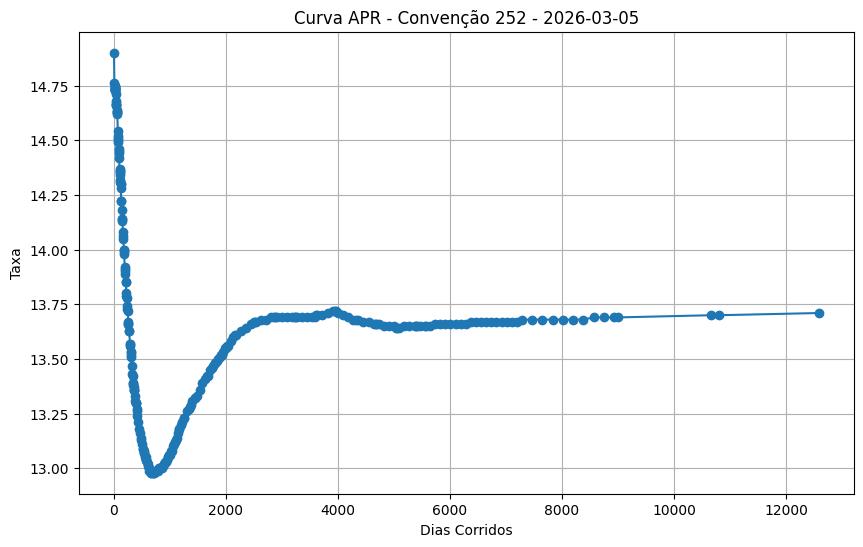

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
# plot
plt.figure(figsize=(10, 6))
plt.plot(curva["dias_corridos"], curva["taxa"], marker="o")
plt.xlabel("Dias Corridos")
plt.ylabel("Taxa")
plt.title(f"Curva APR - Convenção 252 - {data_escolhida}")
plt.grid(True)
plt.show()